In [1]:
import os
import dotenv
import numpy as np
import pandas as pd
import plotly.io as pio
import plotly.express as px
from dotenv import load_dotenv
from sqlalchemy import create_engine , text

In [2]:
load_dotenv()

True

In [3]:
host = os.getenv('SERVERNAME')
db =  os.getenv('DATABASE')
port = os.getenv('PORT')
user = os.getenv('USERNAME')
password = os.getenv('PASS')

### Teste de Conexão

In [4]:
## Aqui tive que buscar ajuda com IA para me lembrar da sequencia da conexão por string 
try:
    conn_string = f"mysql+pymysql://{user}:{password}@{host}:{port}/{db}"
    engine = create_engine(conn_string)
    query = """ SHOW DATABASES """
    teste = pd.read_sql(query,engine)
    print(teste)
except Exception as e:
    print(f"Deu ruim a conexao : {e}")
    exit()

             Database
0  information_schema
1   looqbox-challenge
2  performance_schema


### TESTE SQL

#### 1. What are the 10 most expensive products in the company?

In [5]:
with engine.connect() as conn:
    query = """ SELECT
                    dp.PRODUCT_COD,
                    dp.PRODUCT_NAME,
                    dp.PRODUCT_VAL
                FROM data_product dp
                ORDER BY dp.PRODUCT_VAL DESC
                LIMIT 10 
            """
answer_1 = pd.read_sql(query,engine)

answer_1

,PRODUCT_COD,PRODUCT_NAME,PRODUCT_VAL
0,301409,Whisky Escoces THE MACALLAN Ruby Garrafa 700ml...,741.99
1,176185,Whisky Escoces JOHNNIE WALKER Blue Label Garra...,735.90
2,315481,Cafeteira Expresso 3 CORACOES Tres Modo Vermelho,499.00
3,100280,Vinho Portugues Tinto Vintage QUINTA DO CRASTO...,445.90
4,320046,Escova Dental Eletrica ORAL B D34 Professional...,399.90
5,190817,Champagne Rose VEUVE CLICQUOT PONSARDIM Garraf...,366.90
6,153795,Champagne Frances Brut Imperial MOET Rose Garr...,359.90
7,311397,Conjunto de Panelas Allegra em Inox TRAMONTINA...,359.00
8,147706,Whisky Escoces CHIVAS REGAL 18 Anos Garrafa 750ml,329.90
9,154431,Champagne Frances Brut Imperial MOET & CHANDON...,315.90


#### 2. What sections do the 'BEBIDAS' and 'PADARIA' departments have?

In [6]:
query = """ 
                SELECT
                    dp.SECTION_NAME,
                    dp.DEP_NAME,
                    COUNT(DISTINCT(dp.DEP_NAME)) AS QTD_DEP_NAME
                FROM data_product dp
                WHERE 1=1 
                    AND dp.SECTION_NAME IN ('BEBIDAS','PADARIA')
                GROUP BY
                    dp.SECTION_NAME,
                    dp.DEP_NAME 
                """
answer_2 = pd.read_sql(query,engine)
answer_2

,SECTION_NAME,DEP_NAME,QTD_DEP_NAME
0,BEBIDAS,BEBIDAS,1
1,PADARIA,PADARIA,1


#### 3. What was the total sale of products (in $) of each Business Area in the first quarter of 2019?

#### Aqui pesquisei se havia um método nativo no  MySQL para extrair o trimestre , ao invés de usar o EXTRACT.

In [7]:
# Aqui pesquisei se havia um método nativo no MySQL para extrair o trimestre , ao invés de usar o EXTRACT.
query = """
                SELECT
                    dsc.BUSINESS_NAME AS BUSINESS_AREA,
                    CAST(SUM(dss.SALES_VALUE) AS DECIMAL(18,2)) AS TOTAL_SALE_PRODUCTS 
                FROM data_store_sales dss
                LEFT JOIN data_store_cad dsc ON dsc.STORE_CODE = dss.STORE_CODE 
                WHERE 1=1 
                    AND QUARTER(dss.`DATE`) = 1 
                    AND YEAR(dss.`DATE`) = 2019
                GROUP BY 
                    dsc.BUSINESS_NAME
                ORDER BY 
                    TOTAL_SALE_PRODUCTS DESC
            """
answer_3 = pd.read_sql(query,engine)
answer_3

,BUSINESS_AREA,TOTAL_SALE_PRODUCTS
0,Farma,81776691.73
1,Varejo,81032347.65
2,Atacado,80384884.60
3,Proximidade,80171122.80
4,Posto,32072326.40


### CASE 1

#### Uso de IA para validar a função, achar erro no placeholder do WHERE e melhorar a exibição de erro com try, except. 

In [8]:
def retrieve_data(prod_cod:int, loja_cod:int, lista_data: list[str], engine) -> pd.DataFrame:
    if len(lista_data) != 2:
        raise ValueError("Deve inserir uma lista de datas: [inicio, fim]")
    
    data_ini = lista_data[0]
    data_fim = lista_data[1]

    with engine.connect() as conn:
        query = text("""
                    SELECT * FROM data_product_sales dps
                    WHERE 1=1
                    AND dps.PRODUCT_CODE = :prod_cod
                    AND dps.STORE_CODE = :loja_cod
                    AND dps.DATE >= :data_ini
                    AND dps.DATE <= :data_fim
                """)
        
        params = {
            'prod_cod': int(prod_cod),
            'loja_cod': int(loja_cod),
            'data_ini': data_ini,
            'data_fim': data_fim
            }
    
        try:
            return pd.read_sql(query,conn, params=params)
        except Exception as e:
            print(f'Erro ao buscar os dados:{e}')
            return pd.DataFrame

In [9]:
datas = ['2019-01-01','2019-01-10']
retrieve_data(18,1,datas,engine)

,STORE_CODE,PRODUCT_CODE,DATE,SALES_VALUE,SALES_QTY
0,1,18,2019-01-01,708.5,65.0
1,1,18,2019-01-02,1297.1,119.0
2,1,18,2019-01-03,1144.5,105.0
3,1,18,2019-01-04,1090.0,100.0
4,1,18,2019-01-05,893.8,82.0
5,1,18,2019-01-06,741.2,68.0
6,1,18,2019-01-07,654.0,60.0
7,1,18,2019-01-08,741.2,68.0
8,1,18,2019-01-09,1373.4,126.0
9,1,18,2019-01-10,1068.2,98.0


### CASE 2

In [10]:
query = """
            SELECT
                STORE_CODE,
                STORE_NAME,
                START_DATE,
                END_DATE,
                BUSINESS_NAME,
                BUSINESS_CODE
            FROM data_store_cad dsc
            """
Query_1 = pd.read_sql(query,engine)
Query_1.head(3)

,STORE_CODE,STORE_NAME,START_DATE,END_DATE,BUSINESS_NAME,BUSINESS_CODE
0,1,Sao Paulo,2006-10-01,,Varejo,1
1,2,Chicago,2007-10-01,,Varejo,1
2,3,Roma,2008-10-01,,Varejo,1


In [11]:
query = """
            SELECT
                    STORE_CODE,
                    DATE,
                    SALES_VALUE,
                    SALES_QTY
            FROM data_store_sales
            WHERE DATE BETWEEN '2019-01-01' AND '2019-12-31'
        """
Query_2 = pd.read_sql(query,engine)
Query_2.head(3)

,STORE_CODE,DATE,SALES_VALUE,SALES_QTY
0,1,2019-01-01,196623.22,12838
1,10,2019-01-01,126795.44,4933
2,11,2019-01-01,223937.00,7724


In [12]:
df_join = pd.merge(Query_2, Query_1, on ='STORE_CODE', how='inner')

In [13]:
df_join.head(3)

,STORE_CODE,DATE,SALES_VALUE,SALES_QTY,STORE_NAME,START_DATE,END_DATE,BUSINESS_NAME,BUSINESS_CODE
0,1,2019-01-01,196623.22,12838,Sao Paulo,2006-10-01,,Varejo,1
1,10,2019-01-01,126795.44,4933,Hong Kong,2019-01-01,,Farma,4
2,11,2019-01-01,223937.00,7724,Rio de Janeiro,2019-01-01,,Farma,4


In [14]:
df_stage = df_join[['STORE_NAME','BUSINESS_NAME','DATE','SALES_VALUE','SALES_QTY']].copy()
df_stage['DATE'] = pd.to_datetime(df_stage['DATE'])
df_stage = df_stage[(df_stage['DATE'] >= '2019-10-01') & (df_stage['DATE'] <='2019-12-31')]
df_agrupado = df_stage.groupby(['STORE_NAME','BUSINESS_NAME'])[['SALES_VALUE','SALES_QTY']].sum().reset_index()
df_agrupado['TM'] = (df_agrupado['SALES_VALUE'] / (df_agrupado['SALES_QTY']).replace(0,np.nan)).round(2)
df_agrupado['TM'] = df_agrupado['TM'].fillna(0)
df_agrupado.head(3)

,STORE_NAME,BUSINESS_NAME,SALES_VALUE,SALES_QTY,TM
0,Bahia,Atacado,21213088.57,1378476,15.39
1,Bangkok,Posto,8376271.00,612968,13.67
2,Belem,Proximidade,20989553.37,1365988,15.37


In [15]:
df_ticket_medio = df_agrupado[['STORE_NAME','BUSINESS_NAME','TM']]
df_ticket_medio.rename(columns={'STORE_NAME':'Loja', 'BUSINESS_NAME':'Categoria'}, inplace = True)
df_ticket_medio

,Loja,Categoria,TM
0,Bahia,Atacado,15.39
1,Bangkok,Posto,13.67
2,Belem,Proximidade,15.37
3,Berlin,Proximidade,15.39
4,Buenos Aires,Atacado,15.39
5,Chicago,Varejo,15.53
6,Dubai,Atacado,15.39
7,Hong Kong,Farma,26.35
8,London,Farma,28.99
9,Madri,Farma,29.03


### CASE 3

In [16]:
query = """
        SELECT * FROM IMDB_movies im
        """
df_movies = pd.read_sql(query,engine)
df_movies.head(3)

,Id,Title,Genre,Director,Actors,Year,Runtime,Rating,Votes,RevenueMillions,Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.0,757074,333.0,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.0,65.0
2,3,Split,"Horror,Thriller",M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.0,157606,138.0,62.0


In [17]:
df_movies.shape

(1000, 11)

In [18]:
df_movies.isnull().sum()

Id                   0
Title                0
Genre                0
Director             0
Actors               0
Year                 0
Runtime              0
Rating               0
Votes                0
RevenueMillions    128
Metascore           64
dtype: int64

In [19]:
df_movies_stage = df_movies.copy()
df_clean = df_movies_stage.dropna()
df_clean.info()

<class 'pandas.DataFrame'>
Index: 838 entries, 0 to 999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               838 non-null    int64  
 1   Title            838 non-null    str    
 2   Genre            838 non-null    str    
 3   Director         838 non-null    str    
 4   Actors           838 non-null    str    
 5   Year             838 non-null    int64  
 6   Runtime          838 non-null    int64  
 7   Rating           838 non-null    float64
 8   Votes            838 non-null    int64  
 9   RevenueMillions  838 non-null    float64
 10  Metascore        838 non-null    float64
dtypes: float64(3), int64(4), str(4)
memory usage: 78.6 KB


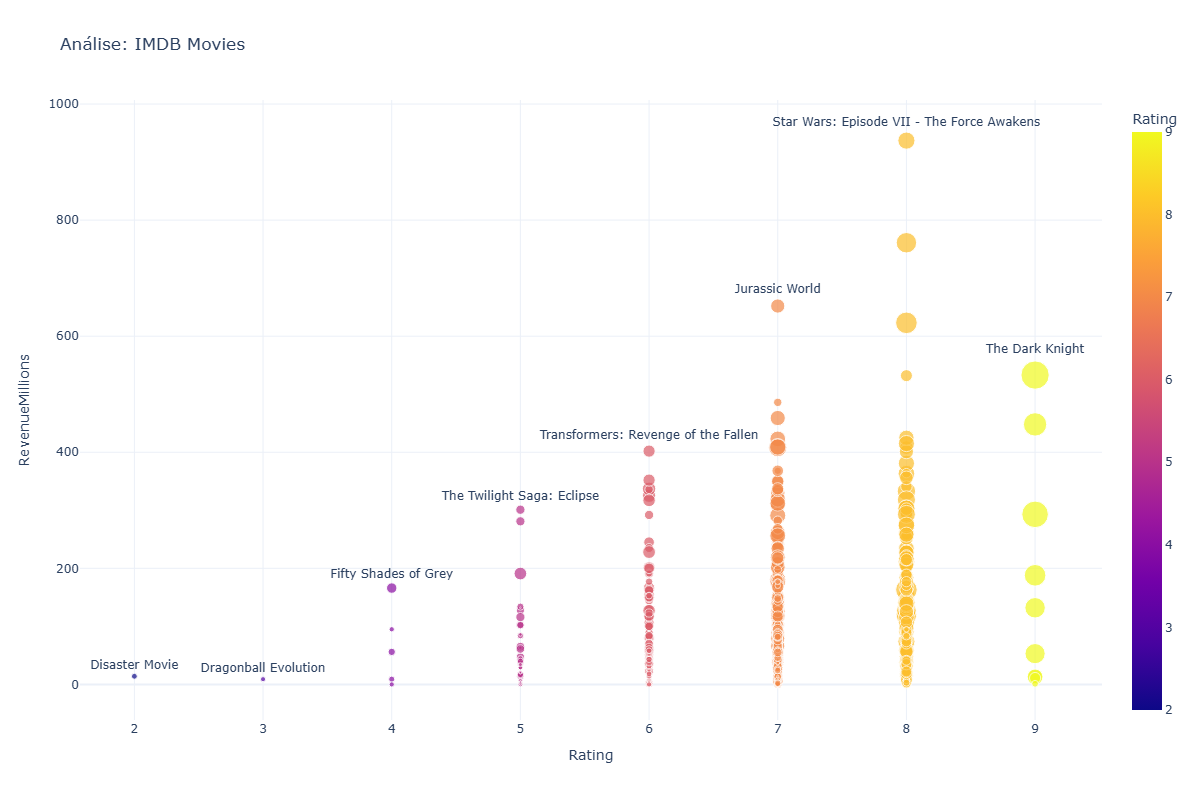

In [20]:
pio.renderers.default = "png"
df_aux = df_clean.sort_values(['Rating', 'RevenueMillions'], ascending=[True, False])
df_clean['Label'] = ''

top_movies = df_clean.loc[df_clean.groupby('Rating')['RevenueMillions'].idxmax(), 'Title']
df_clean.loc[top_movies.index, 'Label'] = df_clean.loc[top_movies.index, 'Title']

fig = px.scatter(
    df_clean,
    width = 1200,
    height = 800,
    x="Rating",
    y="RevenueMillions",
    hover_name="Title",
    size="Votes",
    color="Rating",
    text="Label",
    title="Análise: IMDB Movies",
    template="plotly_white"
)

fig.update_traces(textposition='top center')

fig.show()


### Uso do Grafico scatterplot é interessante pois envolve tres variaveis: Rating , Votes e RevenueMillions, representando o eixo x temos as notas (Rating), eixo Y a Receita em Milhões (RevenueMillions) e os Votos (Votes) sendo representado pelo tamanho da Bolha. Aqui temos uma analise que nos permite verificar se filmes com notas maiores possui uma receita maior. também identificamos outliers para cada grupo de nota (Rating). 